# Food & Restaurant AI Demand Forecasting and Inventory Optimization
## Week 4: Business Evaluation & Final Reporting

- This notebook focuses on translating model results into business insights.
## Objectives:
- Evaluate final model performance
- Visualize predictions vs actual demand
- Interpret feature importance
- Generate business insights
- Provide actionable recommendations

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error

## 2. Loading Data and Model

In [2]:
# test data
test = pd.read_csv('../data/processed/test.csv')

# trained model
model = joblib.load('../models/xgboost_model.pkl')

test.head()

,date,quantity,day,month,year,day_of_week,week_of_year,is_weekend,day_of_week_sin,day_of_week_cos,...,lag_3,lag_7,lag_14,lag_21,rolling_mean_3,rolling_std_3,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14
0,2025-01-22,406,22,1,2025,2,4,0,0.974928,-0.222521,...,463.0,457.0,419.0,432.0,462.000000,1.732051,465.857143,30.856812,456.285714,27.022579
1,2025-01-23,404,23,1,2025,3,4,0,0.433884,-0.900969,...,460.0,463.0,460.0,477.0,443.000000,32.078030,458.571429,38.396428,455.357143,28.580809
2,2025-01-24,370,24,1,2025,4,4,0,-0.433884,-0.900969,...,463.0,426.0,435.0,411.0,424.333333,33.501244,450.142857,43.410554,451.357143,31.636413
3,2025-01-25,450,25,1,2025,5,4,1,-0.974928,-0.222521,...,406.0,529.0,423.0,448.0,393.333333,20.231988,442.142857,52.755501,446.714286,38.291249
4,2025-01-26,447,26,1,2025,6,4,1,-0.781831,0.623490,...,404.0,463.0,460.0,449.0,408.000000,40.149720,430.857143,37.248841,448.642857,37.680044


In [3]:
# Target
y_test = test['quantity']

# Features (droping unnecessary columns)
X_test = test.drop(['quantity', 'date'], axis=1)

print("Test shape:", X_test.shape)

Test shape: (69, 22)


## 4. Generate Predictions

In [4]:
predictions = model.predict(X_test)

In [5]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("Model Performance:")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

Model Performance:
MAE: 28.18
RMSE: 33.72


## 6. Forecast Visualization (Actual vs Predicted)

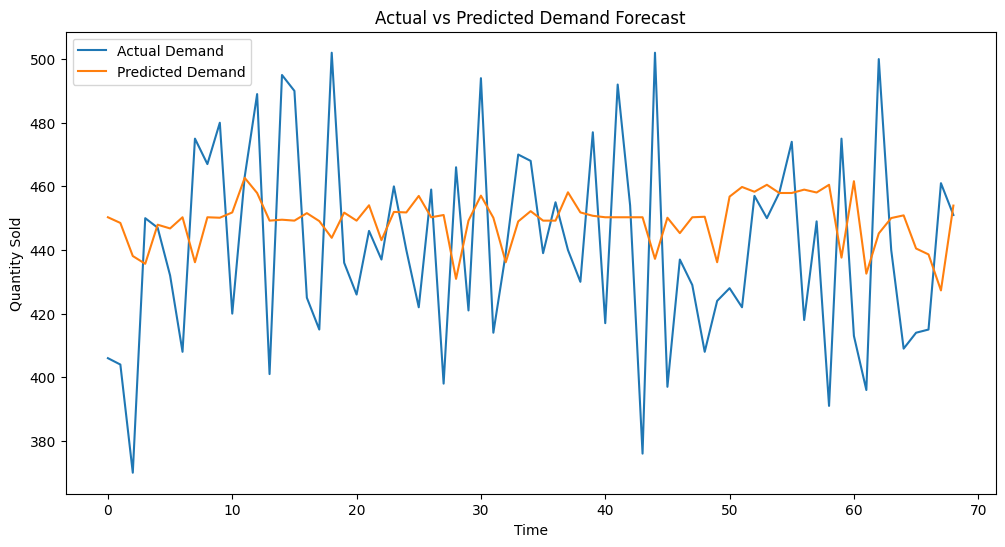

In [6]:
plt.figure(figsize=(12,6))

plt.plot(y_test.reset_index(drop=True), label="Actual Demand")
plt.plot(pd.Series(predictions), label="Predicted Demand")

plt.legend()
plt.title("Actual vs Predicted Demand Forecast")
plt.xlabel("Time")
plt.ylabel("Quantity Sold")

plt.show()

## 7. Residual Analysis

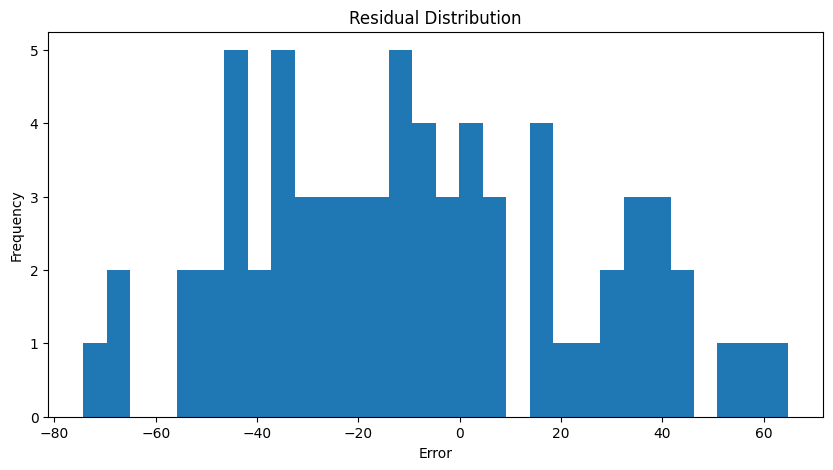

Residual Mean: -8.227354630180027


In [7]:
residuals = y_test.values - predictions

plt.figure(figsize=(10,5))
plt.hist(residuals, bins=30)

plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

print("Residual Mean:", np.mean(residuals))

## 8. Feature Importance Analysis

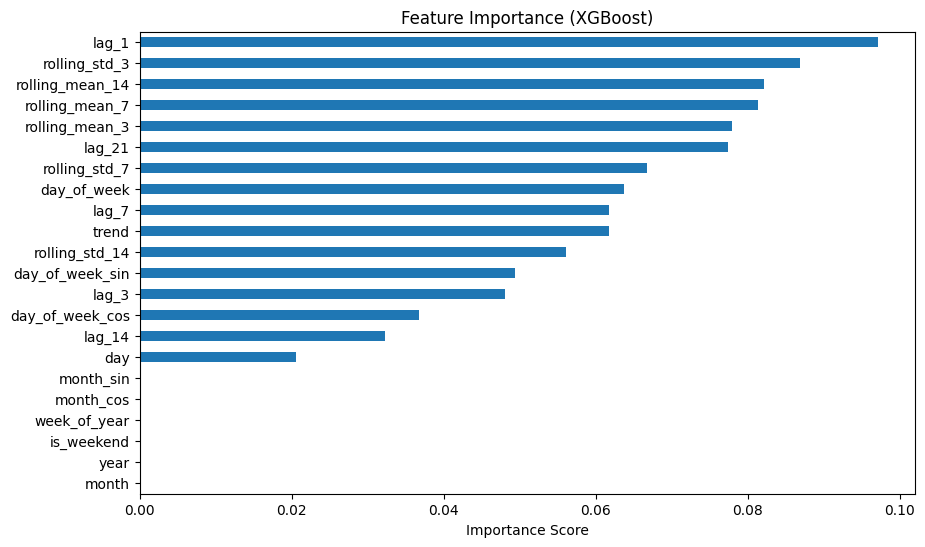

In [8]:
importances = model.feature_importances_
features = X_test.columns

feat_imp = pd.Series(importances, index=features).sort_values()

plt.figure(figsize=(10,6))
feat_imp.plot(kind='barh')

plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")

plt.show()

## 9. Key Feature Insights

In [9]:
top_features = feat_imp.sort_values(ascending=False).head(5)

print("Top 5 Important Features:")
print(top_features)

Top 5 Important Features:
lag_1              0.097111
rolling_std_3      0.086922
rolling_mean_14    0.082176
rolling_mean_7     0.081327
rolling_mean_3     0.077909
dtype: float32


## 10. Business Insights

- Demand is highly influenced by recent sales (lag features)
- Weekly patterns play a significant role in predicting demand.
- Rolling averages help capture demand trends.
- Peak demand periods can be anticipated using the model.

## 11. Business Recommendations

- Optimize inventory based on predicted demand.
- Increase staffing during peak demand days.
- Use forecasts to reduce food waste.
- Plan promotions during low-demand periods.

## 12. Model Limitations

- Model depends heavily on historical data.
- Sudden demand spikes (festivals, events) may not be captured.
- External factors like weather are not included.

## 13. Future Improvements

- Include external data (weather, holidays).
- Try deep learning models (LSTM).
- Deploy model as a real-time forecasting API.

## 14. Final Conclusion

- The model successfully forecasts daily demand using time-series machine learning
- It enables data-driven decision making for restaurant operations.
- This system can improve efficiency, reduce waste, and increase profitability.
